# Support Vector Machines

We initiate our model and analysis by loading the banking dataset.


In [1]:
#@title Import Full Bank File

import pandas as pd

# Read Banking CSV file
url = 'https://raw.githubusercontent.com/johnnydrodriguez/data622/refs/heads/main/bank_full.csv'
bank_df = pd.read_csv(url, delimiter=';')

# Display the first 5 rows
display(bank_df.head())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Separability

We assume the data is separable in the feature space for the SVM to model correctly.

We will validate two kernels:

-  A **linear SVM** assumes the data is linearly separable  using the C parameter.
- A **RBF SVM** assumes the data becomes separable when projected into a higher-dimensional space.



## SVM Data Preparation

We prepare the data to model the SVM by:

1 - Data Cleanup and Preparation
- Identify Missing Values
- Separate Target Feature
- Encode target feature into binary numeric format (0 or 1)

2 - Split Train - Test Data
- We stratify by the target variable to help with class imbalance (necessary for dataset with larege class imbalances).

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Data Cleanup and Prep

#  Replace 'unknown' with numpy.nan
columns_with_unknown = ['job', 'education', 'contact', 'poutcome']
for col in columns_with_unknown:
    bank_df[col] = bank_df[col].replace('unknown', np.nan)

# Separate Features (X) and Target (y)
X = bank_df.drop('y', axis=1)
y = bank_df['y']
print("\nCreated X (features) and y (target).")

#  Encode Target Variable (y)
y = y.map({'no': 0, 'yes': 1})
print("New 'y' value counts (0s and 1s):")
print(y.value_counts())
print("-" * 30 + "\n")

# Train-Test Split

# Statify & Split the Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Verify Stratification
print(f"y_train 'yes' (1) percentage: {y_train.mean() * 100:.2f}%")
print(f"y_test 'yes' (1) percentage:  {y_test.mean() * 100:.2f}%")
print(f"Original 'y' 'yes' (1) percentage: {y.mean() * 100:.2f}%")

print("\nValue counts for y_train:")
print(y_train.value_counts())
print("\nValue counts for y_test:")
print(y_test.value_counts())
print("-" * 30 + "\n")



Created X (features) and y (target).
New 'y' value counts (0s and 1s):
y
0    36548
1     4640
Name: count, dtype: int64
------------------------------

Shape of X_train: (28831, 20)
Shape of X_test: (12357, 20)
Shape of y_train: (28831,)
Shape of y_test: (12357,)
y_train 'yes' (1) percentage: 11.27%
y_test 'yes' (1) percentage:  11.26%
Original 'y' 'yes' (1) percentage: 11.27%

Value counts for y_train:
y
0    25583
1     3248
Name: count, dtype: int64

Value counts for y_test:
y
0    10965
1     1392
Name: count, dtype: int64
------------------------------



## SVM Preprocessing

We will prepocess **both** the test and train datasets before we predict and evaluate the SVM.  To perform this step, we will:

1 - Impute the missing values

2 - Encode features to handle 3 types of features:
- binary encoding - for categorical features with only two possible values.
- ordinal encoding - for categorical features that have a meaningful order.
- one hot encoding for all nominal features - for nominal categorical features where there's no inherent order, such as 'job' or 'marital status'

3 - Scale the features


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# PREPROCESS TRAINING DATASET

# Create a copy to avoid warning
X_train_processed = X_train.copy()

# Define numeric columns
numeric_cols = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# Define categorical columns
categorical_cols = X_train_processed.select_dtypes(include=['object']).columns

# Handle unknown values
columns_to_replace_unknown = ['housing', 'loan']
for col in columns_to_replace_unknown:
    if col in X_train_processed.columns:
        X_train_processed[col] = X_train_processed[col].replace('unknown', np.nan)

# Impute numeric columns
numeric_imputer = SimpleImputer(strategy='median')
X_train_processed[numeric_cols] = numeric_imputer.fit_transform(X_train_processed[numeric_cols])

# Impute categorical columns
categorical_imputer = SimpleImputer(strategy='most_frequent')
X_train_processed[categorical_cols] = categorical_imputer.fit_transform(X_train_processed[categorical_cols])



# Encode Binary Features ('housing', 'loan')
X_train_processed['housing'] = X_train_processed['housing'].map({'no': 0, 'yes': 1})
X_train_processed['loan'] = X_train_processed['loan'].map({'no': 0, 'yes': 1})

# One-Hot Encoding
nominal_cols = categorical_cols.drop(['housing', 'loan'])
X_train_processed = pd.get_dummies(X_train_processed, columns=nominal_cols)
X_train_columns = X_train_processed.columns

# Feature Scaling
scaler = StandardScaler()
X_train_processed[numeric_cols] = scaler.fit_transform(X_train_processed[numeric_cols])

# Encoded and scaled training dataset
print("  Categorical columns imputed with mode (most_frequent).")
display(X_train_processed.head())


  Categorical columns imputed with mode (most_frequent).


,age,housing,loan,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
7309,0.961016,0,0,-0.408114,-0.202499,0.198881,-0.350844,0.648136,0.722717,0.887472,...,False,False,False,False,True,False,False,False,True,False
4169,1.057229,0,0,-0.384959,0.887201,0.198881,-0.350844,0.648136,0.722717,0.887472,...,False,False,False,True,False,False,False,False,True,False
35810,0.576165,1,0,-0.168849,-0.202499,0.198881,-0.350844,-1.198744,-1.181025,-1.231784,...,False,False,False,True,False,False,False,False,True,False
9668,0.576165,1,0,-0.902081,-0.565732,0.198881,-0.350844,0.839193,1.537124,-0.280281,...,False,False,False,True,False,False,False,False,True,False
34389,-1.444302,0,0,1.498288,0.887201,0.198881,-0.350844,-1.198744,-1.181025,-1.231784,...,False,False,False,False,True,False,False,False,True,False


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# PREPROCESS TESTING DATASET

# Create a copy to avoid warning
X_test_processed = X_test.copy()

# Define numeric columns
numeric_cols = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# Define categorical columns
categorical_cols = X_test_processed.select_dtypes(include=['object']).columns

# Handle unknown values
columns_to_replace_unknown = ['housing', 'loan']
for col in columns_to_replace_unknown:
    if col in X_test_processed.columns:
        X_test_processed[col] = X_test_processed[col].replace('unknown', np.nan)

# Impute numeric columns
X_test_processed[numeric_cols] = numeric_imputer.transform(X_test_processed[numeric_cols])

# Impute categorical columns
X_test_processed[categorical_cols] = categorical_imputer.transform(X_test_processed[categorical_cols])

# Encode Binary Features
X_test_processed['housing'] = X_test_processed['housing'].map({'no': 0, 'yes': 1})
X_test_processed['loan'] = X_test_processed['loan'].map({'no': 0, 'yes': 1})

# One-Hot Encoding
nominal_cols = categorical_cols.drop(['housing', 'loan'])
X_test_processed = pd.get_dummies(X_test_processed, columns=nominal_cols)
X_test_processed = X_test_processed.reindex(columns=X_train_columns, fill_value=0)

# Feature Scaling (Standardization)
X_test_processed[numeric_cols] = scaler.transform(X_test_processed[numeric_cols])

# Encoded and scaled test dataset
print(f"OHE shape: {X_test_processed.shape}")
display(X_test_processed.head())


OHE shape: (12357, 57)


,age,housing,loan,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
9923,0.864803,0,0,-0.836476,-0.565732,0.198881,-0.350844,0.839193,1.537124,-0.280281,...,False,False,False,False,False,False,True,False,True,False
3477,1.538292,1,0,-0.411973,-0.202499,0.198881,-0.350844,0.648136,0.722717,0.887472,...,False,False,False,False,True,False,False,False,True,False
12077,-0.482175,0,0,0.537369,-0.565732,0.198881,-0.350844,0.839193,1.537124,-0.280281,...,False,False,True,False,False,False,False,False,True,False
1579,-0.770813,0,0,-0.300059,-0.202499,0.198881,-0.350844,0.648136,0.722717,0.887472,...,False,False,True,False,False,False,False,False,True,False
39993,-1.251877,1,0,1.571611,0.523968,-5.043959,3.634649,-1.135058,0.828192,0.152220,...,False,False,False,False,False,False,True,False,False,True


## SVM Linear Model Trainining and Validation

We will train and evaluate a linear SVM model.

1 - We set kernel = 'linear'

2 - class_weight = 'balanced' to handle the class imbalance by increasing the penalty for the minority 'yes' class

3 - Train the SVM

In [5]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
import time

# Initialize linear SVM
svm_linear = SVC(kernel='linear', class_weight='balanced', random_state=42)
start_time = time.time()

# Fit the model
svm_linear.fit(X_train_processed, y_train)

end_time = time.time()
print(f"Training Complete")
print(f"Total training time: {end_time - start_time:.2f} seconds.")
print("\nThe model 'svm_linear' is now trained and ready for validation.")

Training Complete
Total training time: 65.31 seconds.

The model 'svm_linear' is now trained and ready for validation.


## SVM Linear Model Prediction and Evaluation

              precision    recall  f1-score   support

      no (0)       0.99      0.84      0.91     10965
     yes (1)       0.42      0.92      0.58      1392

    accuracy                           0.85     12357
   macro avg       0.70      0.88      0.74     12357
weighted avg       0.92      0.85      0.87     12357



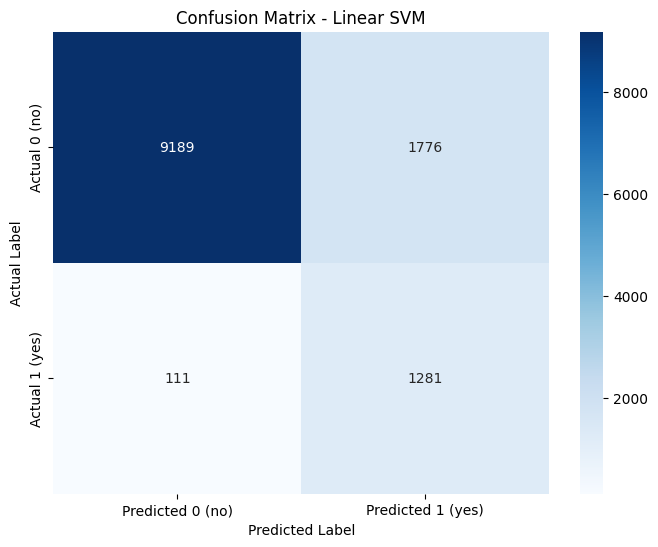

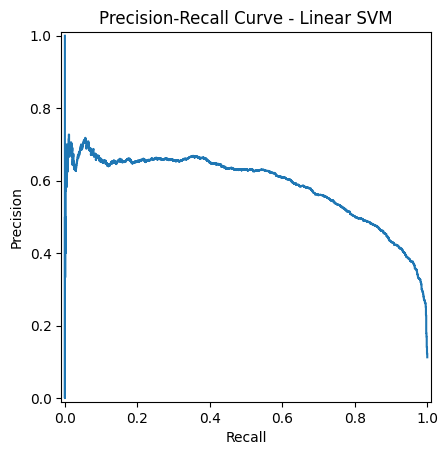

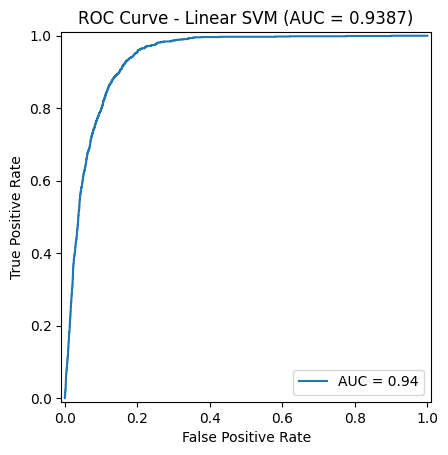

In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    PrecisionRecallDisplay,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay)
import matplotlib.pyplot as plt
import seaborn as sns

# Generate predications
y_pred_linear = svm_linear.predict(X_test_processed)

# Generate score for PR ROC curves
y_score_linear = svm_linear.decision_function(X_test_processed)

# Generate the Classification Report for Target Class
print(classification_report(y_test, y_pred_linear, target_names=['no (0)', 'yes (1)']))

# Generate the Confusion Matrix
cm_linear = confusion_matrix(y_test, y_pred_linear)

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_linear,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0 (no)', 'Predicted 1 (yes)'],
    yticklabels=['Actual 0 (no)', 'Actual 1 (yes)'])
plt.title('Confusion Matrix - Linear SVM')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Calculate PR values
precision, recall, _ = precision_recall_curve(y_test, y_score_linear)

# Plot using PrecisionRecallDisplay
pr_display = PrecisionRecallDisplay(precision=precision, recall=recall)
pr_display.plot()
plt.title('Precision-Recall Curve - Linear SVM')
plt.show()

# Calculate ROC values
fpr, tpr, _ = roc_curve(y_test, y_score_linear)
auc_score = roc_auc_score(y_test, y_score_linear)

# Plot using RocCurveDisplay
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_score)
roc_display.plot()
plt.title(f'ROC Curve - Linear SVM (AUC = {auc_score:.4f})')
plt.show()


## SVM RBF Model Training

We will also train a Radial Basis Function (RBF) SVM.  Due to performance issues and compute limitations, training an RBF using Grid Search was not successful (too long to train).  To improve performance and reduce training time, we fit an RBF using a sub sampling and randomized search grid method.

The Randomized Search Grid allows to find more optimal values of gamma and C than the default values.

In [7]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from scipy.stats import loguniform
import time

# Create a Stratified Subsample
SAMPLE_SIZE = 10000
print(f"Creating stratified subsample of {SAMPLE_SIZE} records...")

# Split off a subsample
X_train_subsample, _, y_train_subsample, _ = train_test_split(
    X_train_processed,
    y_train,
    train_size=SAMPLE_SIZE,
    stratify=y_train,
    random_state=42)
print(f"Subsample created. Shape: {X_train_subsample.shape}")


# Initialize SVM model
svc_rbf = SVC(kernel='rbf', class_weight='balanced', random_state=42)

# Define the distributions to search.
param_dist = {
    # Search C from 0.1 to 100 on a log scale
    'C': loguniform(0.1, 100),
    # Search gamma from 0.001 to 1 on a log scale
    'gamma': loguniform(0.001, 1)}
print(f"Parameter distributions to search (using loguniform): {param_dist}")

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=svc_rbf,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42)

# Train the SVM model
start_time = time.time()

# Fit the random search object on the SUBSAMPLE
random_search.fit(X_train_subsample, y_train_subsample)

end_time = time.time()
print(f"Randomized Search Complete")
print(f"Total training time: {end_time - start_time:.2f} seconds.")

# Results
print("\nBest F1-score found during cross-validation (on subsample):")
print(f"{random_search.best_score_:.4f}")

print("\nBest parameters found:")
print(random_search.best_params_)


Creating stratified subsample of 10000 records...
Subsample created. Shape: (10000, 57)
Parameter distributions to search (using loguniform): {'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c803bdcbfb0>, 'gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c803bdcbf20>}
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Randomized Search Complete
Total training time: 96.62 seconds.

Best F1-score found during cross-validation (on subsample):
0.5771

Best parameters found:
{'C': np.float64(31.428808908401084), 'gamma': np.float64(0.004335281794951566)}


## SVM Prediction and Evaluation

Generating predictions on X_test_processed using the best RBF model...
Generated scores for PR/ROC curves.

RBF SVM Classification Report (Target Class 1 = 'yes'):
              precision    recall  f1-score   support

      no (0)       0.99      0.84      0.91     10965
     yes (1)       0.42      0.92      0.58      1392

    accuracy                           0.85     12357
   macro avg       0.71      0.88      0.75     12357
weighted avg       0.92      0.85      0.87     12357

Confusion Matrix


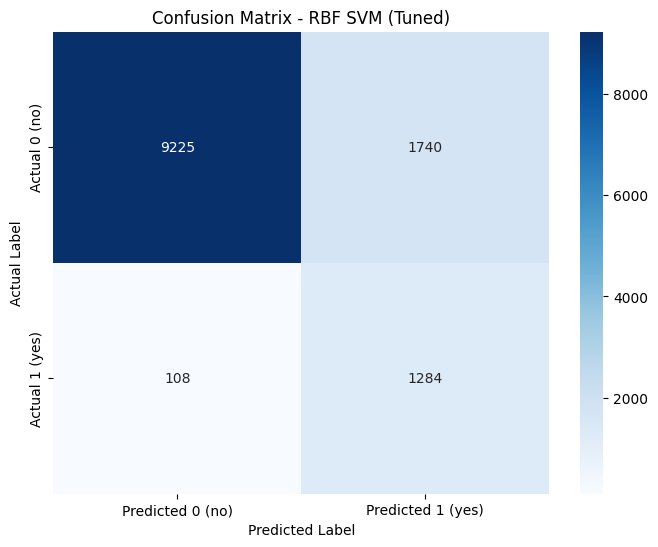

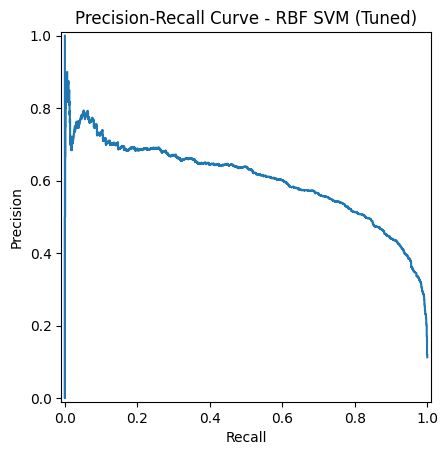

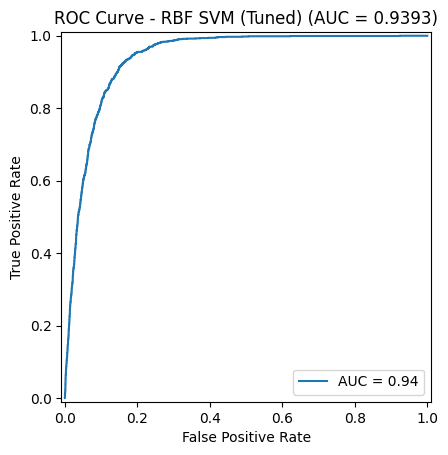

In [8]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    PrecisionRecallDisplay,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay)
import matplotlib.pyplot as plt
import seaborn as sns


# Generate Predictions
print("Generating predictions on X_test_processed using the best RBF model...")
y_pred_rbf = random_search.predict(X_test_processed)

# Generate scores for the  PR and ROC curves
y_score_rbf = random_search.decision_function(X_test_processed)
print("Generated scores for PR/ROC curves.")

# Generate the Classification Report
print("\nRBF SVM Classification Report (Target Class 1 = 'yes'):")
print(classification_report(y_test, y_pred_rbf, target_names=['no (0)', 'yes (1)']))

# Generate the Confusion Matrix
print("Confusion Matrix")
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

# Confusion Matrix Heatmap (RBF)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_rbf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0 (no)', 'Predicted 1 (yes)'],
    yticklabels=['Actual 0 (no)', 'Actual 1 (yes)'])
plt.title('Confusion Matrix - RBF SVM (Tuned)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

#  Precision-Recall (PR) Curve (RBF)

# Calculate PR values
precision_rbf, recall_rbf, _ = precision_recall_curve(y_test, y_score_rbf)

# Plot using PrecisionRecallDisplay
pr_display = PrecisionRecallDisplay(precision=precision_rbf, recall=recall_rbf)
pr_display.plot()
plt.title('Precision-Recall Curve - RBF SVM (Tuned)')
plt.show()

#  ROC Curve (RBF)

# Calculate ROC values
fpr_rbf, tpr_rbf, _ = roc_curve(y_test, y_score_rbf)
auc_score_rbf = roc_auc_score(y_test, y_score_rbf)

# Plot using RocCurveDisplay
roc_display = RocCurveDisplay(fpr=fpr_rbf, tpr=tpr_rbf, roc_auc=auc_score_rbf)
roc_display.plot()
plt.title(f'ROC Curve - RBF SVM (Tuned) (AUC = {auc_score_rbf:.4f})')
plt.show()


## Model Comparison Table

In [9]:
import pandas as pd

# Data for the table
data = {
    'Metric': ['Precision (class 1)', 'Recall (class 1)', 'F1-Score (class 1)', 'AUC'],
    'Linear SVM': [0.42, 0.92, 0.58, 0.9387],
    'RBF SVM': [0.42, 0.92, 0.58, 0.9393]
}

# Create DataFrame
df_comparison = pd.DataFrame(data)

# Set Metric as index
df_comparison = df_comparison.set_index('Metric')

print("Model Performance Comparison:")
display(df_comparison)

Model Performance Comparison:


,Linear SVM,RBF SVM
Metric,,
Precision (class 1),0.4200,0.4200
Recall (class 1),0.9200,0.9200
F1-Score (class 1),0.5800,0.5800
AUC,0.9387,0.9393


## Conclusions

Based on the evaluation of the Linear and RBF kernel Support Vector Machine models, here is a summary of their results:

**Linear SVM:**

*   **Precision (for 'yes' / class 1):** 0.42
*   **Recall (for 'yes' / class 1):** 0.92
*   **F1-Score (for 'yes' / class 1):** 0.58
*   **AUC:** 0.9387

**RBF SVM (Sub Sampled with Randomized Grid Search):**

*   **Precision (for 'yes' / class 1):** 0.42
*   **Recall (for 'yes' / class 1):** 0.92
*   **F1-Score (for 'yes' / class 1):** 0.58
*   **AUC:** 0.9393

Both models perform very similarly, especially when considering metrics for the minority class ('yes' or 1).

*   **High Recall:** Both models demonstrate a high ability to identify positive cases (Recall = 0.92). The models  are good at finding potential subscribers.

*   **Moderate Precision:** The identical precision for both models indicates that they also identify a significant number of false positives (predicting 'yes' when the actual outcome is 'no').

*   **Similar F1-Scores and AUC:** The F1-scores (0.58) and AUC values (around 0.939) are nearly identical; this suggests similar overall performance and discriminative power despite the different kernels.

Both the linear and RBF SVM models, when using `class_weight='balanced'`, are effective at identifying a large proportion of potential subscribers (high recall). However, their ability to avoid false positives (precision) is moderate. The choice between the two kernels doesn't appear to make a significant difference in performance based on these metrics; due the significantly increased compute needed for the RBF kernel without improvement to model performance, the linear SVM is the recommended model.